### **👩‍🏫 👩🏿‍🏫 What You'll Learn**

- Data visualization with scatter plots.
- Basic understanding of classification models
- Interpreting the results.

---

### **🛠️ What You Will Create**

In this notebook, you will be using 4 classification models- Logistic Regression, K Nearest Neighbours, Random Forests and Support Vector Machines (SVM).

---

### **Your Task**

### **Exploratory Data Analysis**

- Use `pandas` to load the dataset and examine the first few rows.
- Check and handle the missing values.
- Drop any unnecessary column
- Create a Countplot to display `diagnosis` from `magma`

### **Data Preprocessing, Building Models and Evaluation**

- Counts of unique rows in the `diagnosis` column
- Map categorical values to numerical values
- Splitting the data into train and test
- Implement logistic regression and print the accuracy.
- Implement K Nearest Neighbours and print the accuracy.
- Implement Random Forests and print the accuracy.
- Implement Support Vector Machines (SVM) and print the accuracy.
- Which is the best model?


In [25]:
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [4]:
dataset_path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

100%|██████████| 48.6k/48.6k [00:00<00:00, 26.4MB/s]

Extracting files...


In [9]:
df = pd.read_csv(f"{dataset_path}/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### Checking for Missing Values

Before doing any cleaning, we will explore the dataset and look for missing values.


In [10]:
df.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


Confirmed we don't have any missing values in the dataset.

---

### Dropping Unnecessary Columns

`Unnamed: 32` is a fully-null artifact of a trailing comma in the CSV, and `id` is just a row identifier with no predictive value. Neither belong in the feature set and can be dropped.


In [ ]:
df = df.drop(columns=["id", "Unnamed: 32"])
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Visualizing the Diagnosis Distribution

A countplot shows how many benign (B) vs malignant (M) cases are in the dataset (`diagnosis` column), using the `magma` palette as requested in the instructions.


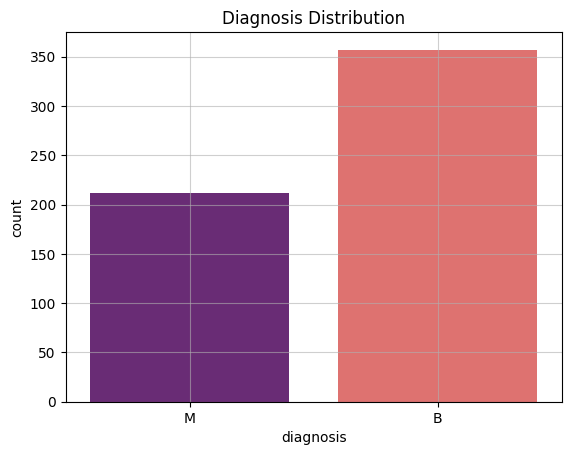

In [14]:
sns.countplot(x="diagnosis", data=df, hue="diagnosis", palette="magma")
plt.title("Diagnosis Distribution")
plt.grid(alpha=0.6)
plt.show()

### Diagnosis Value Counts

Before encoding, we will confirm the exact counts behind the plot above.


In [15]:
df["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


### Encoding the Diagnosis Column

Classification models need numeric labels, so we map diagnosis in such way that benign will be set to 0, and malignant set to 1, since that's the outcome we care about detecting.


In [ ]:
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})
df["diagnosis"].value_counts()

,count
diagnosis,
0,357
1,212


### Train / Test Split

We separate features (X) from the diagnosis label (y), then hold out 20% of the data to evaluate the models on data they haven't seen during training.


In [17]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Feature Scaling

Features in this dataset are on a very different scales (e.g `area_mean` in the hundreds vs `smoothness_mean` under 1).
Logistic Regression, KNN and SVM are all sensitive to it. Without scaling, Logistic Regression fails to converge, so we need to standardize the features before training any model.


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

A baseline linear classifier for the diagnosis outcome.


In [20]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
log_reg_preds = log_reg.predict(X_test_scaled)
log_reg_acc = accuracy_score(y_test, log_reg_preds)

print(f"Logistic Regression Accuracy: {log_reg_acc:.4f}")

Logistic Regression Accuracy: 0.9649


### KNN

Classifies each test point by majority vote among its `K` nearest neighbors (defaults to 5) in the scaled feature space. This is exactly why scaling mattered here, since KNN relies directly on distance between points.


In [21]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_preds)

print(f"KNN Accuracy: {knn_acc:.4f}")

KNN Accuracy: 0.9561


### Random Forest

An ensemble of decision trees voting on the diagnosis. Unlike KNN and Logistic Regression, tree splits don't care about feature scale, but reusing the already-scaled data doesn't hurt, so we keep the pipeline consistent.


In [22]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.9737


### Support Vector Machine

Finds the boundary that best separates benign from malignant cases, maximizing the margin between classes. Like KNN, SVM's margin calculation is scale-sensitive, so the standardized features matter here too.


In [23]:
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
svm_preds = svm.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_preds)

print(f"SVM Accuracy: {svm_acc:.4f}")

SVM Accuracy: 0.9737


### Model Comparison

Comparing accuracy across all four models to pick the best performer.


In [ ]:
results = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "KNN", "Random Forest", "SVM"],
        "Accuracy": [log_reg_acc, knn_acc, rf_acc, svm_acc],
    }
)

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
3,SVM,0.973684
2,Random Forest,0.973684
0,Logistic Regression,0.964912
1,KNN,0.956140


### Comparing Random Forest and SVM with a Confusion Matrix

Since Random Forest and SVM tied on accuracy (`0.9737`), we look at their confusion matrices to see whether they're making the same kind of mistakes, where a false negative (missing a malignant case) is far more dangerous than a false positive, since this is a cancer diagnosis task.


In [ ]:
for name, preds in [("Random Forest", rf_preds), ("SVM", svm_preds)]:
    cm = confusion_matrix(y_test, preds)
    print(f"{name} confusion matrix:")
    print(cm)
    print(f"False negatives (malignant predicted as benign): {cm[1][0]}\n")

Random Forest confusion matrix:
[[72  0]
 [ 3 39]]
False negatives (malignant predicted as benign): 3

SVM confusion matrix:
[[72  0]
 [ 3 39]]
False negatives (malignant predicted as benign): 3



### Conclusion

Both Random Forest and SVM tied on accuracy (as discussed above), and their confusion matrices are identical as well.
Given that information, picking which model is best, comes down to different criterions (e.g training speed, interpretability, implementation difficulty).
